In [1]:
import archs4py as a4
import pandas as pd
import numpy as np

#path to file
file = "./data/human_tpm_v2.latest.h5"

In [2]:
meta_meta = a4.meta.meta(file, "liver", meta_fields=["characteristics_ch1", "source_name_ch1", 'library_source', 'library_strategy', 'molecule_ch1'])

100%|██████████| 5/5 [00:08<00:00,  1.75s/it]


In [3]:
#take only samples that collected all RNA
meta_subset = meta_meta[meta_meta.molecule_ch1 == 'total RNA']
#remove cell lines
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('cell line')]
#remove cancer and diseased samples
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('cancer')]
meta_subset = meta_subset[~meta_subset.characteristics_ch1.str.contains('disease')]
#meta_subset = meta_subset[meta_subset['characteristics_ch1'].str.contains('normal|healthy|Healthy')]

In [4]:
meta_subset_IDs = list(meta_subset.index)

In [5]:
sample_counts = a4.data.samples(file, meta_subset_IDs)

100%|██████████| 12537/12537 [00:15<00:00, 804.26it/s]


In [17]:
#filters genes that don't have at least 'readThreshold' reads in 'sampleThreshold' proportion of samples
filtered_exp = a4.utils.filter_genes(sample_counts, readThreshold=50, sampleThreshold=0.50, deterministic=True, aggregate=True)
filtered_exp

,GSM1076108,GSM1101972,GSM1306652,GSM1306653,GSM1363505,GSM1363506,GSM1363507,GSM1363508,GSM1363509,GSM1363510,...,GSM9201913,GSM9201914,GSM9201915,GSM9201916,GSM9258368,GSM9279098,GSM9279101,GSM9279102,GSM9279103,GSM9279104
A1BG,223,32,19898,11123,0,11,0,3,0,0,...,27529,23081,30299,33926,11106,6743,3644,6418,3806,10383
A1CF,94,17,4405,7988,0,0,0,0,0,4,...,8367,7653,6719,3860,168,20841,11698,17178,12376,17321
A2M,8546,11998,32791,31732,0,0,0,744,1,1,...,240065,221219,250470,202002,6558,47068,34633,50591,96067,116840
AAAS,709,77,520,408,0,0,0,0,0,0,...,1513,1854,1935,2282,1217,227,271,276,330,396
AACS,212,344,121,56,0,0,0,0,0,0,...,194,240,217,214,5960,225,232,247,278,334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,731,190,410,516,0,0,0,0,0,0,...,1505,1616,1399,1320,1418,753,735,643,640,702
ZYG11B,440,1430,584,791,0,0,0,2,0,0,...,818,759,601,331,3748,1818,1442,4346,1773,3523
ZYX,3674,162,962,484,0,0,0,0,0,0,...,4292,2012,5402,7744,10656,224,280,356,526,522
ZZEF1,1429,1127,519,641,0,0,0,4,0,0,...,1399,1367,1516,2087,5469,1172,953,1384,1276,1588


In [7]:
#sampleThreshold = 0.00: SHOULD BE ALL GENES. 62548 genes
#RT = 100, sampleThreshold = 0.02: 24,210 genes
#RT = 1000, sampleThreshold = 0.02: 13,116 genes

In [18]:
agg_exp = a4.utils.aggregate_duplicate_genes(filtered_exp)

In [ ]:
agg_exp = agg_exp.T

In [12]:
agg_exp.sum(axis=0) > 100000

Series([], dtype: bool)

In [13]:
final_exp = agg_exp.loc[agg_exp.sum(axis=1) > 100000]
final_exp = agg_exp[agg_exp.sum(axis=0) > 100000]

/tmp/ipykernel_12002/319337290.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  final_exp = agg_exp[agg_exp.sum(axis=0) > 100000]


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [ ]:
final_exp

,A1BG,A1CF,A2M,AAAS,AACS,AADAC,AADAT,AAGAB,AAK1,AAMDC,...,ZSWIM8,ZUP1,ZW10,ZWILCH,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
GSM1076108,223,94,8546,709,212,48,58,425,512,156,...,2465,307,221,157,129,731,440,3674,1429,676
GSM1101972,32,17,11998,77,344,4,73,357,1233,185,...,559,110,266,70,223,190,1430,162,1127,1551
GSM1306652,19898,4405,32791,520,121,4234,901,252,156,354,...,1731,41,172,46,187,410,584,962,519,419
GSM1306653,11123,7988,31732,408,56,5355,1199,202,163,214,...,2278,39,194,66,241,516,791,484,641,484
GSM1363505,0,0,0,0,0,0,3,0,0,0,...,1,0,0,0,2,0,0,0,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM9279098,6743,20841,47068,227,225,4101,1393,174,645,129,...,1495,68,257,89,705,753,1818,224,1172,971
GSM9279101,3644,11698,34633,271,232,2949,709,264,796,86,...,1138,85,214,71,493,735,1442,280,953,757
GSM9279102,6418,17178,50591,276,247,6145,752,344,1100,72,...,1742,111,279,72,559,643,4346,356,1384,964
GSM9279103,3806,12376,96067,330,278,2008,168,373,1229,48,...,1374,119,378,83,782,640,1773,526,1276,929


(array([1.185e+04, 2.320e+02, 7.900e+01, 5.500e+01, 1.800e+01, 6.000e+00,
        2.000e+00, 4.000e+00, 0.000e+00, 1.000e+00]),
 array([1.00360000e+05, 7.12589722e+07, 1.42417584e+08, 2.13576197e+08,
        2.84734809e+08, 3.55893421e+08, 4.27052033e+08, 4.98210645e+08,
        5.69369258e+08, 6.40527870e+08, 7.11686482e+08]),
 <BarContainer object of 10 artists>)

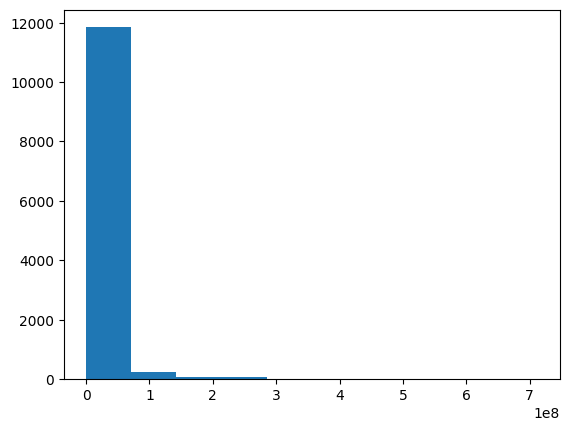

In [ ]:
import matplotlib.pyplot as plt

plt.hist(final_exp.sum(axis = 1))

In [ ]:
#remove samples where total TPM < 100,000 across all genes
# remove rows
agg_exp = agg_exp.loc[agg_exp.sum(axis=1) > 100000]

# remove columns
agg_exp = agg_exp.loc[:, agg_exp.sum(axis=0) > 100000]

In [ ]:
agg_exp.loc['GSM1363505', :].sum()

np.uint64(279686)

In [ ]:
#agg_exp.T.to_csv('./data/ARCHS4_healthy.tsv', sep = '\t')